# Phase 6: Model Evaluation & Explainability

In this notebook, we will evaluate our final tuned XGBoost model using:
1. **Confusion Matrix Heatmap** - To see where the model makes correct/incorrect predictions.
2. **ROC-AUC Curve** - To measure classification power across all probability thresholds.
3. **SHAP Summary Plot** - To explain which features influence predictions the most and how.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import shap
import os
import warnings
warnings.filterwarnings('ignore')

# Fix working directory if run inside notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Current Working Directory: {os.getcwd()}")

# Use default style
sns.set_theme(style="whitegrid")

Current Working Directory: D:\Projects\UFC-fight-predection


In [2]:
# Load processed features
print("Loading features...")
df = pd.read_csv("data/processed/ufc-ml-features.csv")
df['date'] = pd.to_datetime(df['date'])

# Chronological split (Training: pre-2023, Test: 2023+)
train_df = df[df['date'] < '2023-01-01'].copy()
test_df = df[df['date'] >= '2023-01-01'].copy()

cols_to_drop = ['date', 'R_fighter', 'B_fighter']

X_train = train_df.drop(columns=cols_to_drop + ['Winner'])
y_train = train_df['Winner']

X_test = test_df.drop(columns=cols_to_drop + ['Winner'])
y_test = test_df['Winner']

print(f"Train set: {X_train.shape[0]} fights")
print(f"Test set: {X_test.shape[0]} fights")

Loading features...
Train set: 5524 fights
Test set: 1645 fights


In [3]:
# Train the final model with best hyperparameters
best_params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
print("Training final tuned XGBoost model...")
model = XGBClassifier(eval_metric='logloss', random_state=42, **best_params)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, model.predict_proba(X_test)):.4f}")

Training final tuned XGBoost model...


Accuracy: 0.6802
Log Loss: 0.6038


## 1. Confusion Matrix Heatmap

Let's see where the model gets confused:

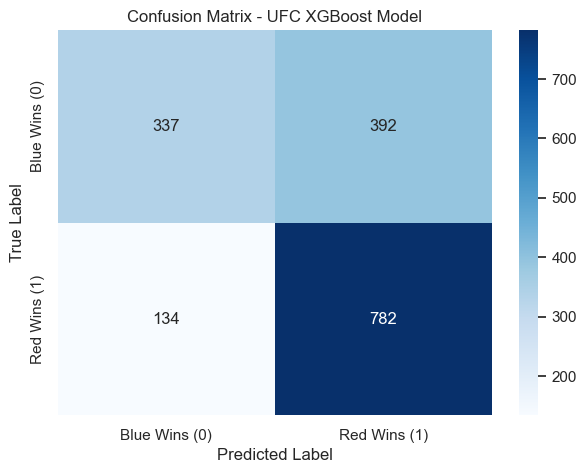

               precision    recall  f1-score   support

Blue Wins (0)       0.72      0.46      0.56       729
 Red Wins (1)       0.67      0.85      0.75       916

     accuracy                           0.68      1645
    macro avg       0.69      0.66      0.65      1645
 weighted avg       0.69      0.68      0.67      1645



In [4]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Blue Wins (0)', 'Red Wins (1)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - UFC XGBoost Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
os.makedirs("docs", exist_ok=True)
plt.savefig('docs/confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

## 2. ROC Curve & AUC Score

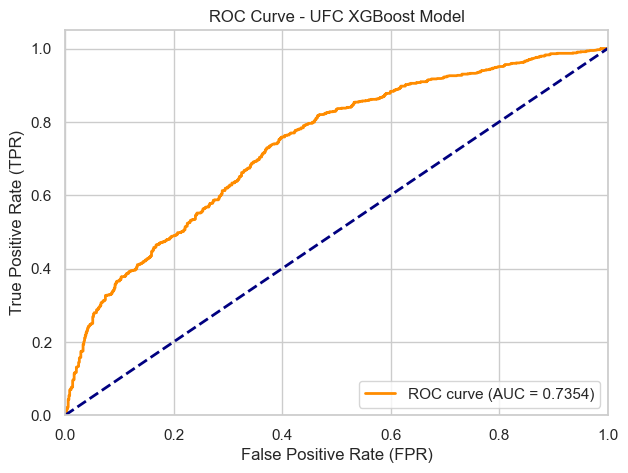

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - UFC XGBoost Model')
plt.legend(loc="lower right")
plt.savefig('docs/roc_curve.png', bbox_inches='tight')
plt.show()

## 3. SHAP Explainability Summary Plot

Calculating SHAP values...


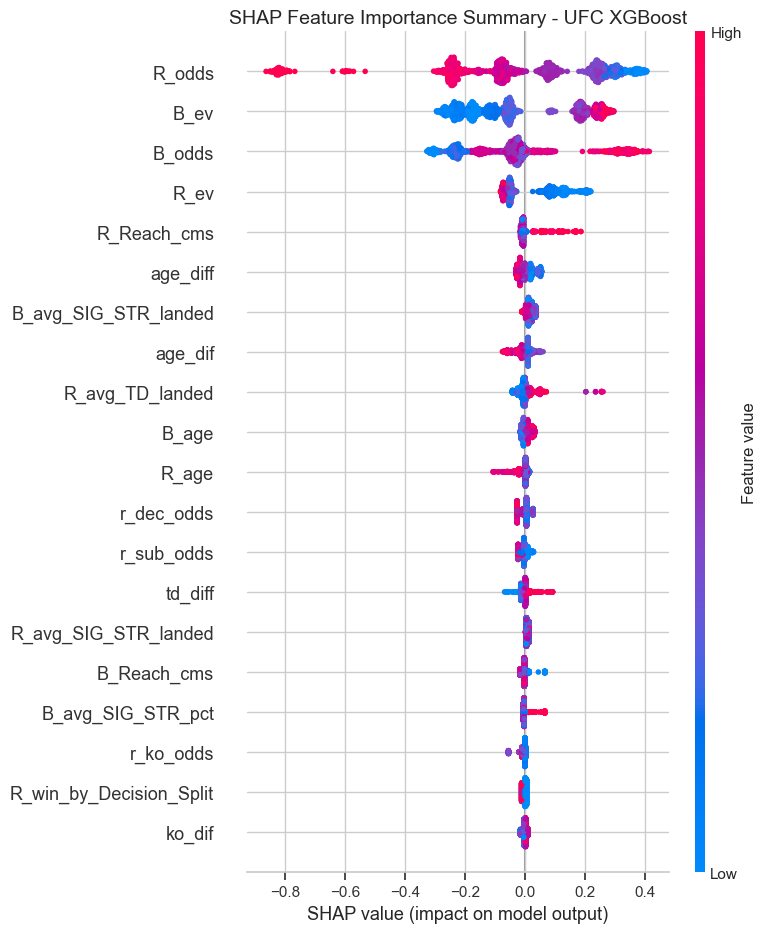

In [6]:
# Initialize SHAP TreeExplainer
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Plot summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance Summary - UFC XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig('docs/shap_summary.png', bbox_inches='tight')
plt.show()